In [454]:
"""
Automatically reloads libraries and utilities every time a cell is run
"""
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [455]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils.PSF_helpers import *
from utils.Plot_helpers import *
from utils.Zernike_helpers import *
from utils.Booth_helpers import *
from utils.Phase_diversity_helpers_cupy import *

In [456]:
#minor style things to make the figures look nice
plt.style.use("bmh")
plt.rcParams["figure.figsize"] = [548 / 72, 390 / 72]
plt.rcParams["font.size"] = 12
plt.rcParams['text.usetex'] = True
plt.rcParams["figure.dpi"] = 300
import os
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

In [519]:
N_order = 3              # 3 for 3P, 2 for 2P
lambd = 1.3e-3            # Wavelength [mm]
n = 1.333                  # Refractive index
k = 2*n*np.pi/lambd        # Wavenumber
num_apt = 1.05            # Numerical aperture
focal = 7.2                    # Focal length of objective (Olympus) [mm]
mag = np.nan                   # Magnification rate from input to objective
w_0 = np.nan                 # mm
alpha = np.arcsin(num_apt / n)

#106.5 microns
#L_ffp = 0.1065
L_ffp = 0.01
#512 x 512
grid_ffp = 512
grid = Centered_Square_Grid(L_ffp, grid_ffp, 0)
#CONJUGATE BFP LENGTH
grid_bfp = grid_ffp
L_bfp = (lambd * focal * grid_bfp) / L_ffp
microscope = Microscope(N_order, lambd, n, num_apt, focal, mag, w_0, L_bfp, grid_bfp)
x, y = grid.get_xy()
x_bfp = x * (L_bfp/ L_ffp)
y_bfp = y * (L_bfp/ L_ffp)



In [535]:
f = np.load("images/usaf_resolution.npy") * 1e18
rng = np.random.default_rng(15)
true_aberration = generate_johnson_aberration(523/523, alpha, rng)

In [536]:
def add_gaussian_noise(image, SNR, rng):
    sigma_noise = np.percentile(image, 90) / SNR
    return image + rng.normal(0, sigma_noise, image.shape)
    

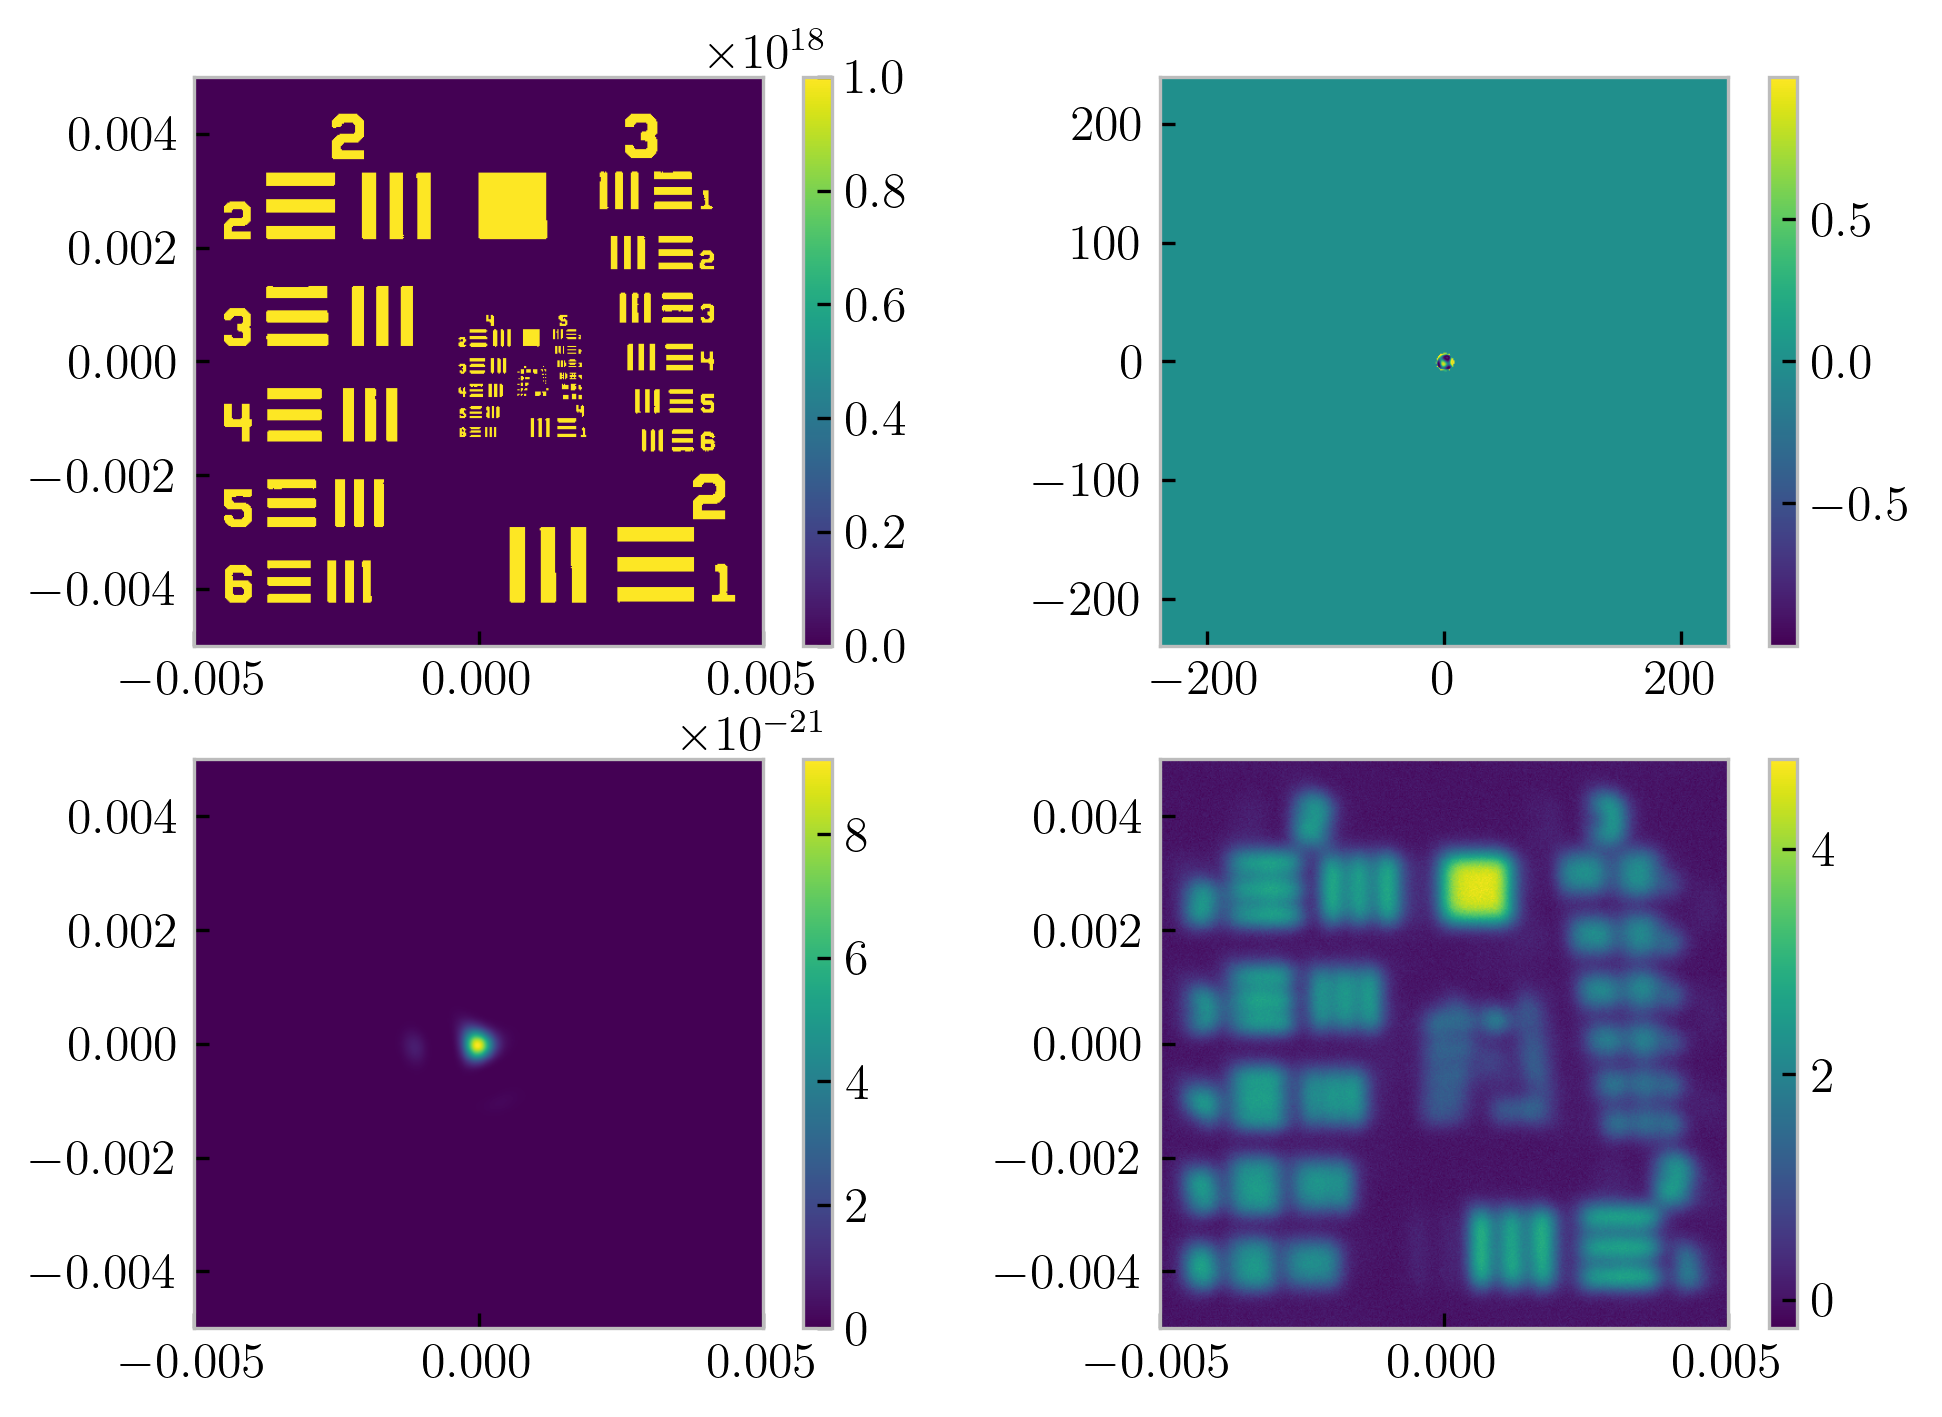

In [537]:
SNR = 30

H = forward_H(microscope, true_aberration)
PSF = forward_PSF(microscope, true_aberration)
#plot_intensity(x, y, PSF, normalize = False)
d = forward_image(microscope, f, true_aberration)
d = add_gaussian_noise(d, SNR, rng)
#plot_intensity(x, y, d, normalize = False)

fig, axs = plt.subplots(2, 2)
axs = axs.flatten()

im0 = axs[0].imshow(f,
                    extent=[x[0], x[-1], y[0], y[-1]],)

im1 = axs[1].imshow(np.imag(H),
                    extent=[x_bfp[0], x_bfp[-1], y_bfp[0], y_bfp[-1]],)

im2 = axs[2].imshow(PSF,
                    extent=[x[0], x[-1], y[0], y[-1]],)

im3= axs[3].imshow(d,
                   extent=[x[0], x[-1], y[0], y[-1]],)

for ax in axs:
    ax.grid(False)
    #ax.set_xticks([])
    #ax.set_yticks([])



fig.colorbar(im0, ax = axs[0])
fig.colorbar(im1, ax = axs[1])
fig.colorbar(im2, ax = axs[2])
fig.colorbar(im3, ax = axs[3])

In [538]:
bias_modes = [[-2,2]]#, [0,2], [2,2],
#[0, 4], [-4,4], [4,4]]
bias_strength = 500/523
a_stack = [EmptyAberration()] + [Aberration([m], [bias_strength]) for m in bias_modes]
d_stack = np.array([get_diversity_image(microscope, f, true_aberration, a) for a in a_stack])
d_stack = [add_gaussian_noise(d, SNR, rng) for d in d_stack]

IndexError: list index out of range

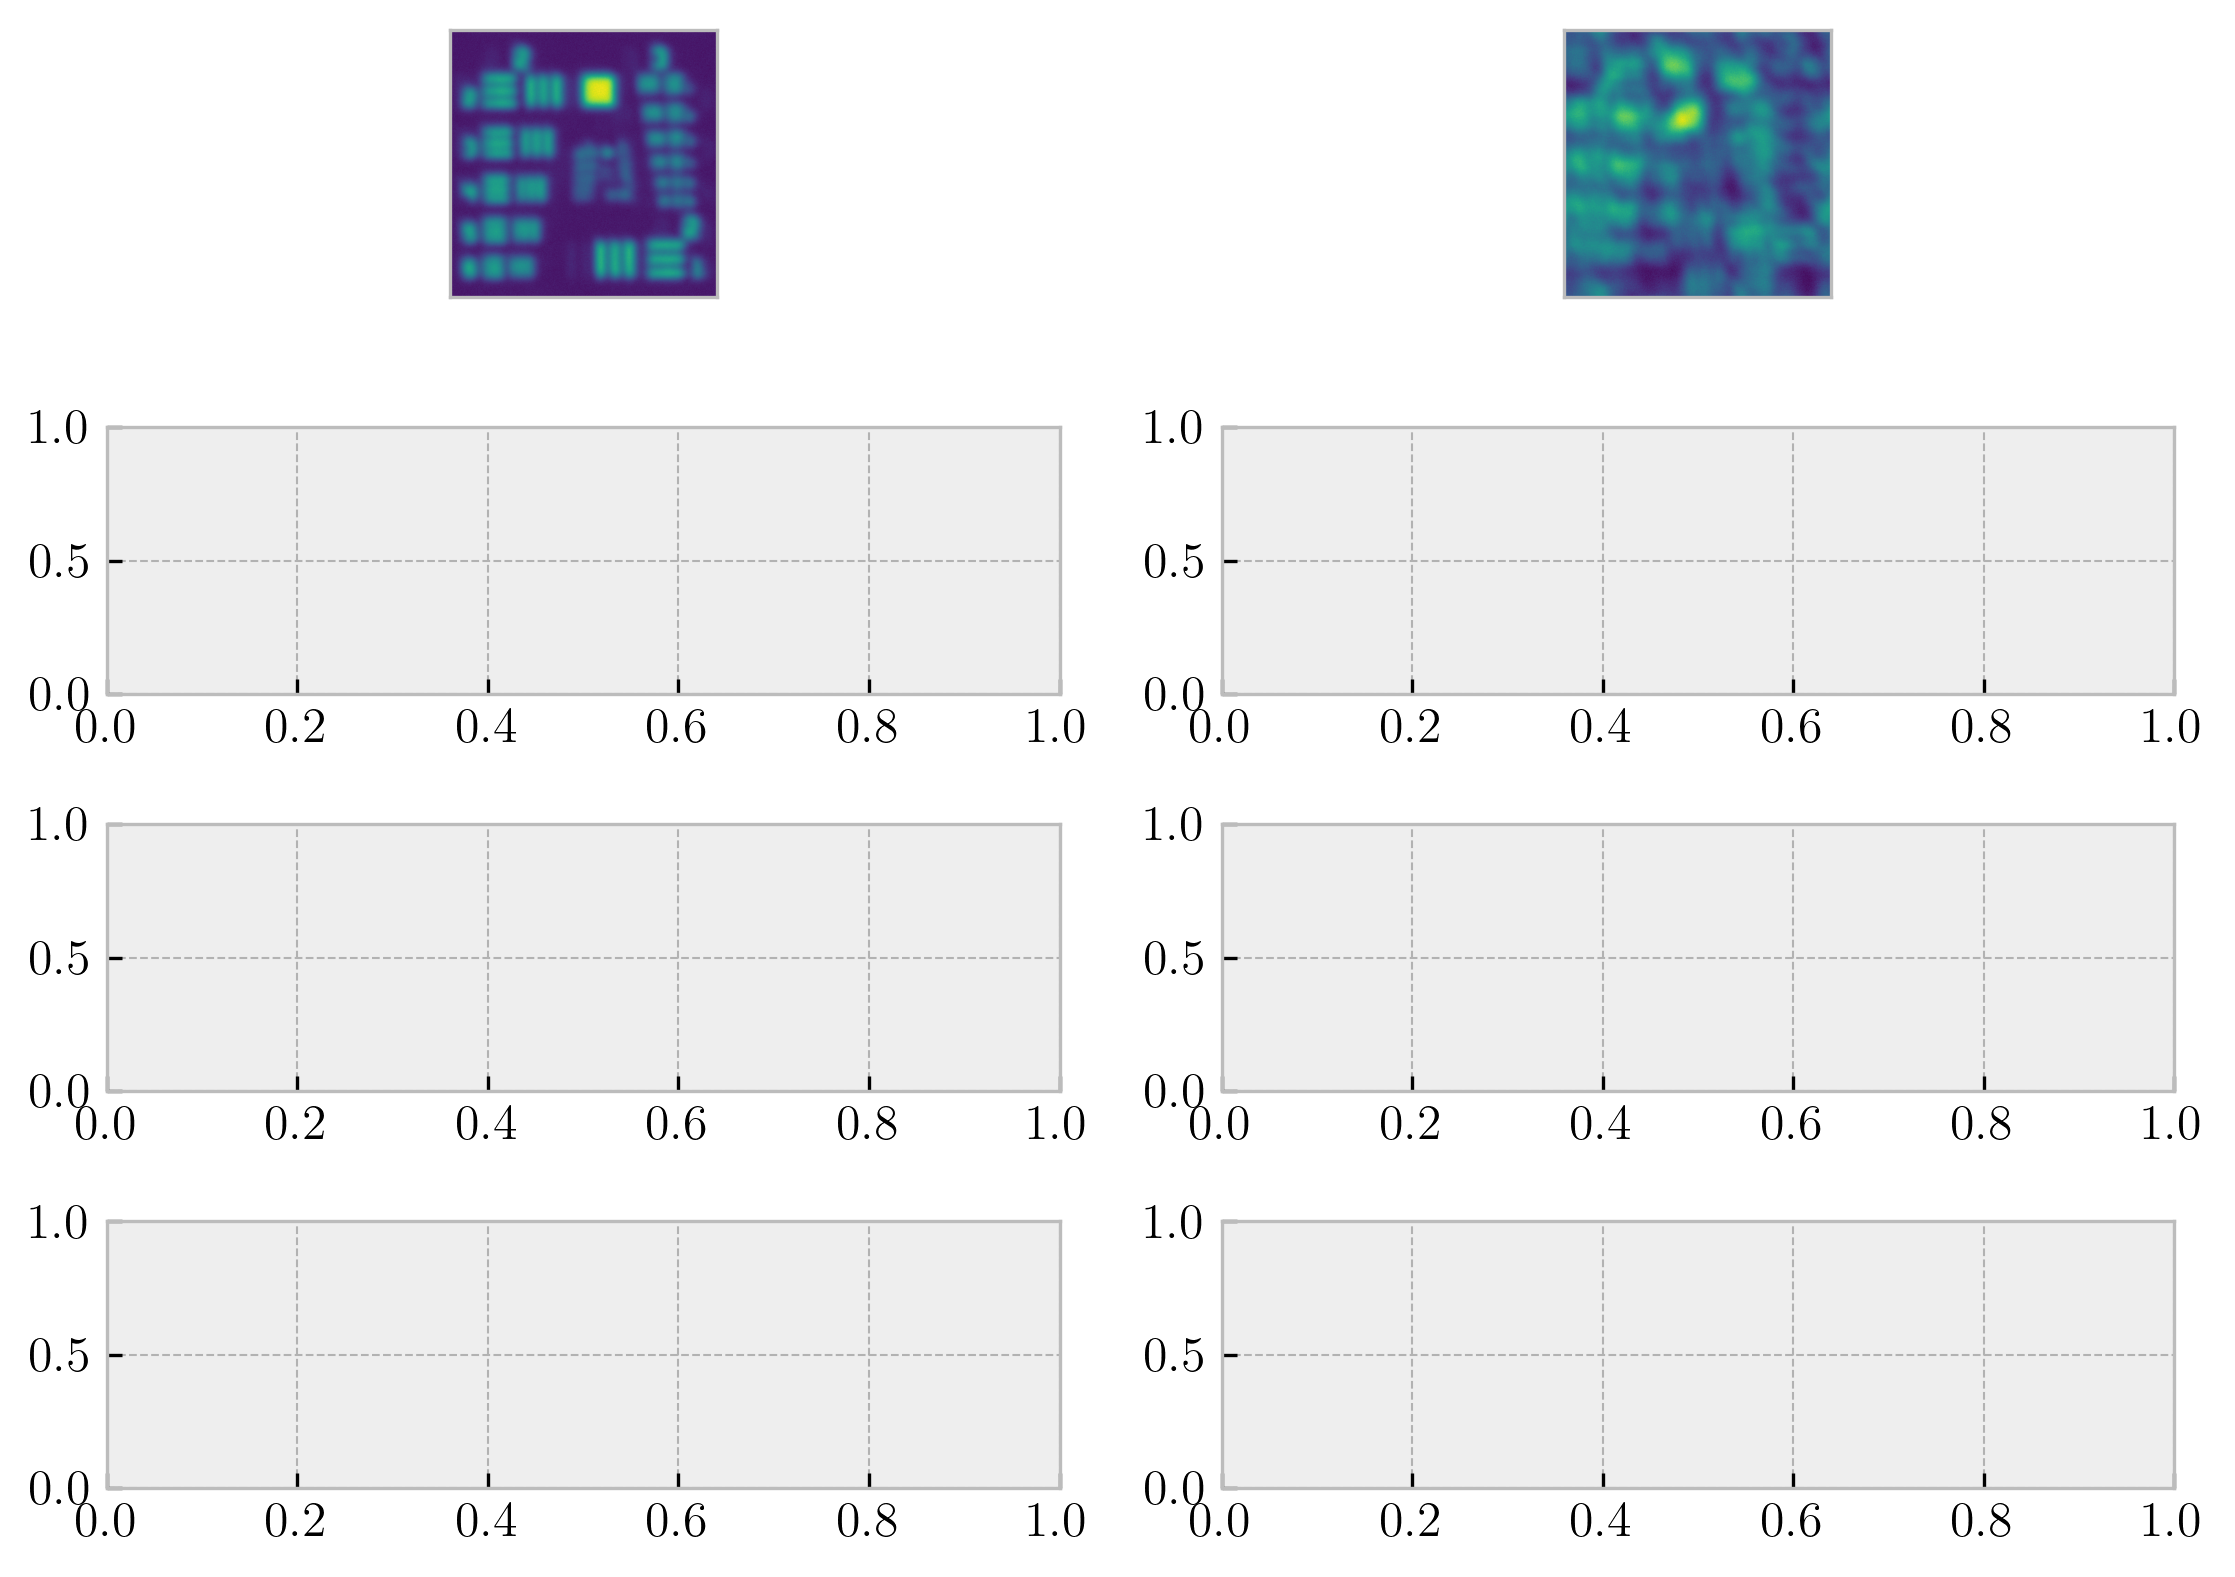

In [539]:
a = 4
b = 2
fig, axs = plt.subplots(a, b, layout = "tight")
axs = axs.flatten()
for i in range(a*b):
    axs[i].imshow(d_stack[i])
    axs[i].grid(False)
    axs[i].set_xticks([])
    axs[i].set_yticks([])

In [540]:
params = {
    "gamma": 1e-9,
    "J_tol": 0.001,
    "max_step": 0.1
}

c_guess, F_guess  = loop_optimize(n_loops = 100,
                                            microscope = microscope,
                                            d_stack = d_stack,
                                            a_stack = a_stack,
                                            modes_corrected = modes_corrected,
                                            params = params,
                                            debug = True,
                                            log = False)

  0%|          | 0/100 [00:00<?, ?it/s]

Loop 1: J = 83774046208.0
Corrercted Zernike Mode: [[-2  2]
 [ 0  2]
 [ 2  2]
 [-3  3]
 [-1  3]
 [ 1  3]
 [ 3  3]
 [-4  4]
 [-2  4]
 [ 0  4]
 [ 2  4]
 [ 4  4]
 [-5  5]
 [-3  5]
 [-1  5]
 [ 1  5]
 [ 3  5]]
Estimated Zernike Coefficients: [0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001
 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001]
	 Estimated object in 0.004 seconds
	 Estimated gradient in 0.013 seconds


  1%|          | 1/100 [00:00<00:30,  3.30it/s]

	 Estimated Hessian in 0.254 seconds
Loop 2: J = 83774046208.0
Corrercted Zernike Mode: [[-2  2]
 [ 0  2]
 [ 2  2]
 [-3  3]
 [-1  3]
 [ 1  3]
 [ 3  3]
 [-4  4]
 [-2  4]
 [ 0  4]
 [ 2  4]
 [ 4  4]
 [-5  5]
 [-3  5]
 [-1  5]
 [ 1  5]
 [ 3  5]]
Estimated Zernike Coefficients: [-0.00101674 -0.01237945 -0.06002242 -0.00231951  0.0012975   0.0004608
  0.00144079  0.00015118 -0.0021341  -0.03834914  0.01687714 -0.06649517
  0.00054096 -0.00077895 -0.00256421 -0.00296653 -0.00128067]
	 Estimated object in 0.004 seconds
	 Estimated gradient in 0.012 seconds


  2%|▏         | 2/100 [00:00<00:26,  3.65it/s]

...

  9%|▉         | 9/100 [00:02<00:22,  3.97it/s]

	 Estimated Hessian in 0.205 seconds
Loop 10: J = 83774046208.0
Corrercted Zernike Mode: [[-2  2]
 [ 0  2]
 [ 2  2]
 [-3  3]
 [-1  3]
 [ 1  3]
 [ 3  3]
 [-4  4]
 [-2  4]
 [ 0  4]
 [ 2  4]
 [ 4  4]
 [-5  5]
 [-3  5]
 [-1  5]
 [ 1  5]
 [ 3  5]]
Estimated Zernike Coefficients: [-0.11734212 -0.05498847 -0.00116169 -0.09991748  0.10912948  0.02084847
  0.0513751   0.02181937 -0.0571061   0.02724995  0.04190544 -0.06562085
  0.04390946 -0.04790986 -0.01513193 -0.08350371 -0.06081049]
	 Estimated object in 0.005 seconds
	 Estimated gradient in 0.013 seconds


 10%|█         | 10/100 [00:02<00:24,  3.71it/s]

	 Estimated Hessian in 0.197 seconds
Loop 11: J = 83774046208.0
Corrercted Zernike Mode: [[-2  2]
 [ 0  2]
 [ 2  2]
 [-3  3]
 [-1  3]
 [ 1  3]
 [ 3  3]
 [-4  4]
 [-2  4]
 [ 0  4]
 [ 2  4]
 [ 4  4]
 [-5  5]
 [-3  5]
 [-1  5]
 [ 1  5]
 [ 3  5]]
Estimated Zernike Coefficients: [-0.1259927  -0.05625057  0.07322086 -0.09228786  0.1140531   0.01908788
  0.05967046  0.02799795 -0.0620508   0.04818086  0.00920722 -0.05166901
  0.01502909 -0.0196187  -0.00643785 -0.10083269 -0.03932691]
	 Estimated object in 0.004 seconds
	 Estimated gradient in 0.013 seconds


KeyboardInterrupt: 

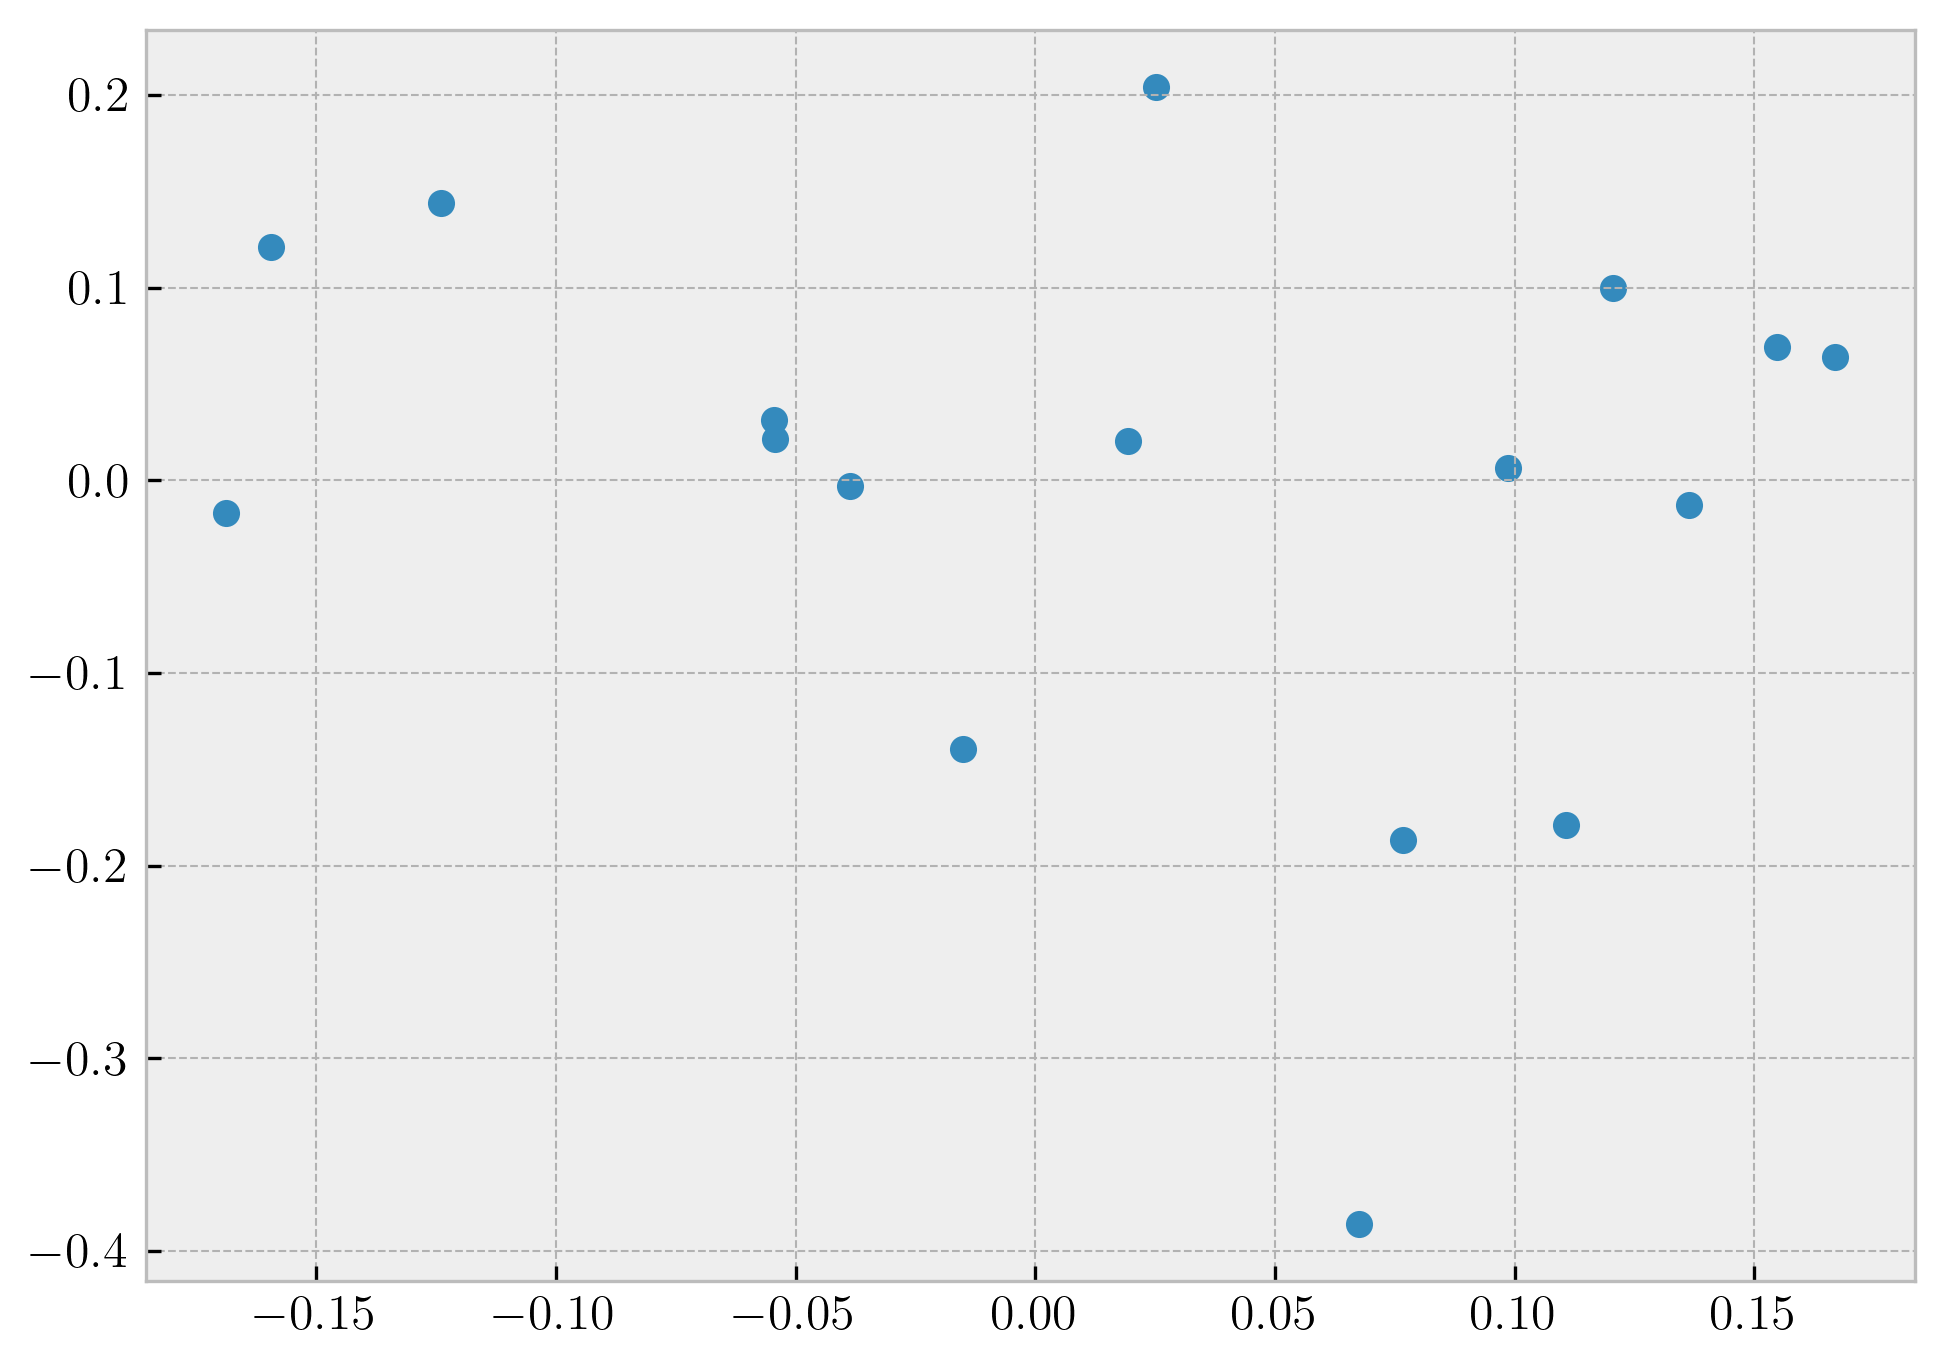

In [ ]:
plt.scatter(np.array(true_aberration.strengths), c_guess)

In [ ]:
zernike_RMS(true_aberration, alpha)

np.float64(1.0)

In [531]:
zernike_RMS(true_aberration - Aberration(modes_corrected, c_guess), alpha)

np.float64(2.0213847665146787)

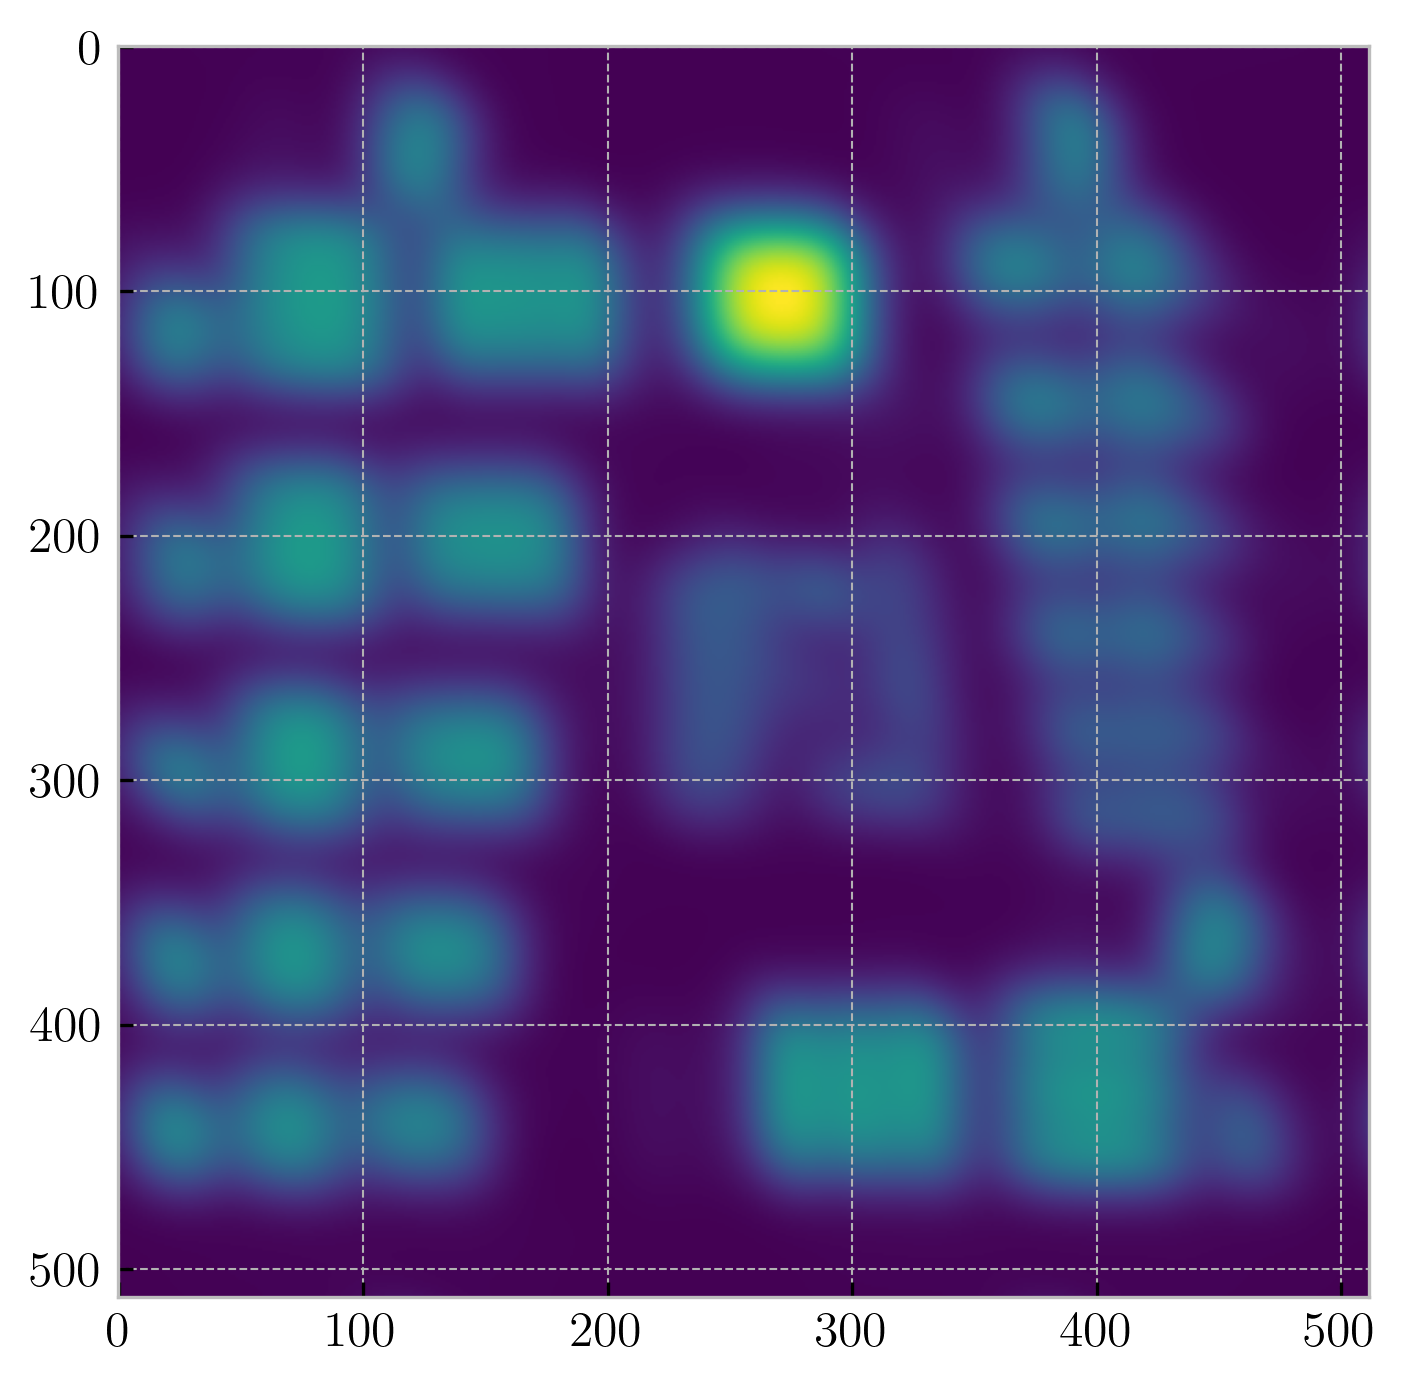

In [532]:
plt.imshow(np.real(np.fft.ifft2(F_guess)))

In [545]:
max_steps = [0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]
gamma_vals = [10**(-x) for x in range(1, 31)]
num_samples = 1

SNR = 30

modes_corrected = get_johnson_modes()

rng = np.random.default_rng(15)

bias_modes = [[-2,2]]
bias_strength = 500/523 
a_stack = [EmptyAberration()] + [Aberration([m], [bias_strength]) for m in bias_modes]

c_converged = np.zeros((num_samples, len(max_steps), len(gamma_vals), len(modes_corrected)))
c_true = np.zeros((num_samples, len(max_steps), len(gamma_vals), len(modes_corrected)))
for i in range(num_samples):

    true_aberration = generate_johnson_aberration(150/523, alpha, rng)
    img_stack = np.array([get_diversity_image(microscope, f, true_aberration, a) for a in a_stack])

    for j, max_step in enumerate(max_steps):
        d_stack = [add_gaussian_noise(img, SNR, rng) for img in img_stack]
        
        
        for k, gamma in enumerate(gamma_vals):
            params = {
            "gamma": gamma,
            "J_tol": 0.001,
            "max_step": max_step
            }

            c_guess, F_guess  = loop_optimize(n_loops = 100,
                                                    microscope = microscope,
                                                    d_stack = d_stack,
                                                    a_stack = a_stack,
                                                    modes_corrected = modes_corrected,
                                                    params = params,
                                                    debug = False,
                                                    log = False)
                    
            c_converged[i, j, k] = c_guess
            c_true[i, j, k] = true_aberration.strengths

100%|██████████| 100/100 [00:28<00:00,  3.45it/s]


In [546]:
np.save("max_step_c_true.npy", c_true)
np.save("max_step_c_converged.npy", c_converged)